# Spatial Analysis 

1. Ganze Stadt Zürich über letzte 10 Jahre barchart
    - evt. für jedes Jahr eine Choroplethenkarte, wie hat sich die Verteilung geändert
2. Pro Quartier letzte 10 Jahre
3. Häufigste Meldung und wie ist diese räunlich verteilt


In [4]:
# Imports
import geopandas as gpd
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

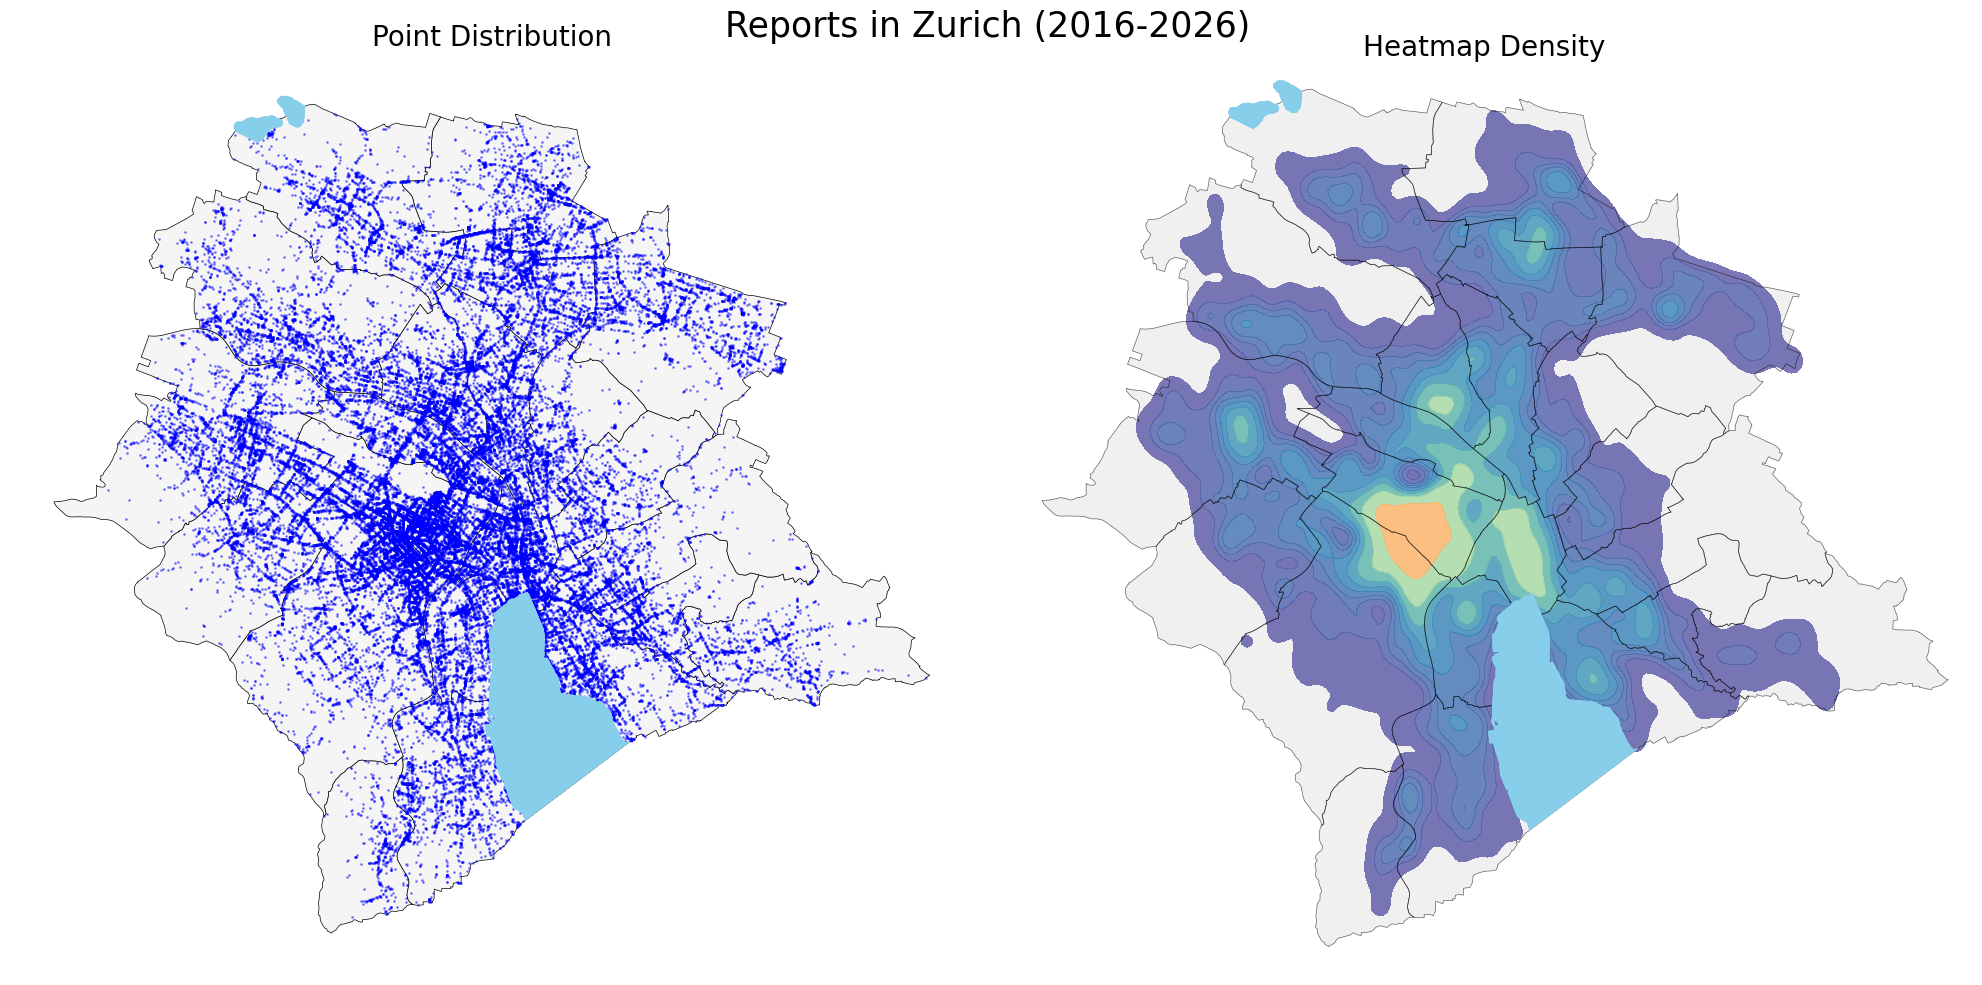

In [34]:
# Load the quartiere polygons
BASE_DIR = Path().resolve().parent
quartiere_file_path = BASE_DIR / "data/raw/Zurich_quarters.gpkg"
quartiere_gdf = gpd.read_file(quartiere_file_path)

# Load the lakes
lakes_file_path = BASE_DIR / "data/processed/lakes_zh.gpkg"
lakes_gdf = gpd.read_file(lakes_file_path)
lakes_gdf = lakes_gdf.to_crs(epsg=2056)

# Load the cleaned reports
reports_file_path = BASE_DIR / "data/processed/reports_cleaned.csv"
reports_df = pd.read_csv(reports_file_path)
reports_gdf = gpd.GeoDataFrame(
    reports_df, geometry=gpd.points_from_xy(reports_df.e, reports_df.n, crs="EPSG:2056")
)

# First visualisation
fig, axs = plt.subplots(1, 2, figsize=(20,10))
fig.suptitle("Reports in Zurich (2016-2026)", fontsize=25)

# Point distribution
quartiere_gdf.plot(ax=axs[0], color="whitesmoke", edgecolor="black", linewidth= 0.5)
reports_gdf.plot(ax=axs[0], color= "blue", markersize=1, alpha=0.4)
lakes_gdf.plot(ax=axs[0], color = "skyblue")
axs[0].axis("off")
axs[0].set_title("Point Distribution", fontsize=20)

# 2. Heatmap (Kernel Density Estimate)
quartiere_gdf.plot(ax=axs[1], color="#f0f0f0", edgecolor="none")

sns.kdeplot(
    x=reports_gdf.e, y=reports_gdf.n, 
    ax=axs[1], 
    cmap="Spectral_r", 
    fill=True, 
    thresh=0.05, # ab welcher Dichte die Heatmap angezeigt wird (> 5% des maximalen Wertes)
    alpha=0.8, 
    bw_adjust=0.5  # Beeinflusst, wie glatt die Heatmap ist
)

lakes_gdf.plot(ax=axs[1], color = "skyblue", zorder= 2)
quartiere_gdf.boundary.plot(ax=axs[1], color="black", linewidth=0.5, alpha=0.6, zorder=1) # only the boundaries

axs[1].axis("off")
axs[1].set_title("Heatmap Density", fontsize=20)

plt.tight_layout() # that they don't overlap
plt.show()


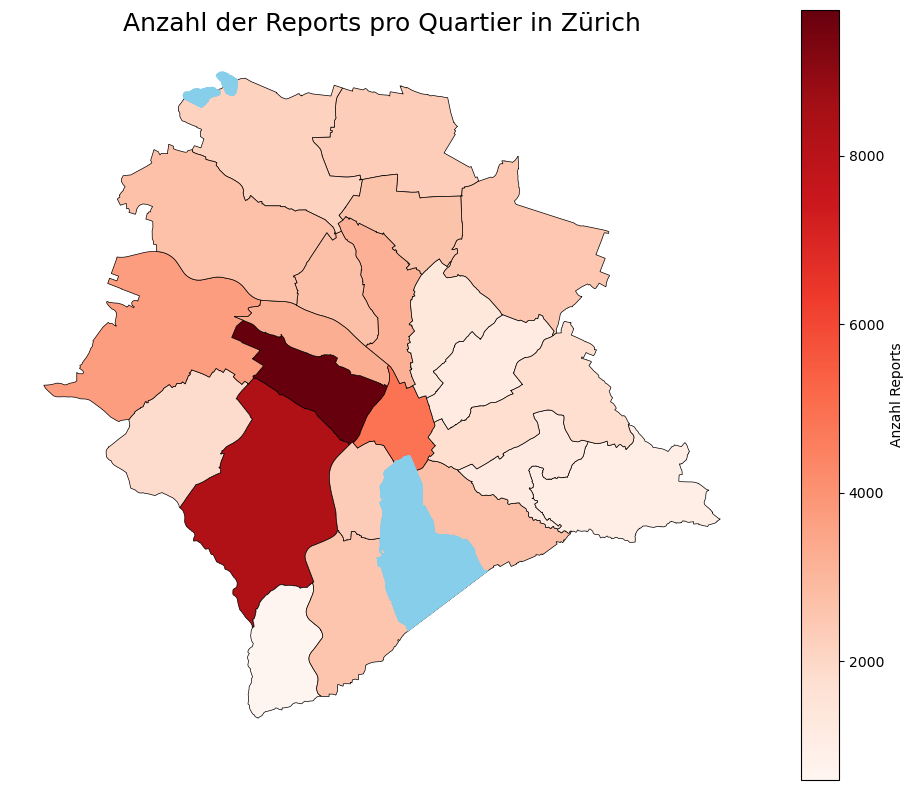

In [ ]:
# Reports pro Quartier in Choroplethenkarte
# Spatial Join
reports_quartiere_gdf = gpd.sjoin(reports_gdf, quartiere_gdf, how="inner", predicate="within")
report_counts = reports_quartiere_gdf.groupby("name").size().reset_index(name="count")
quartiere_counts_gdf = quartiere_gdf.merge(report_counts, on="name", how="left")

# Chorplethenkarte erstellen

fig, ax = plt.subplots(figsize=(12,10))
lakes_gdf.plot(ax=ax, color="skyblue",zorder=2)

quartiere_counts_gdf.plot(
    column="count",         
    cmap="Reds",             
    legend=True,                
    legend_kwds={'label': "Anzahl Reports", 'orientation': "vertical"},
    edgecolor="black",          
    linewidth=0.5,
    ax=ax,
    zorder=1
)

ax.set_title("Anzahl der Reports pro Quartier in Zürich", fontsize=18)
ax.axis("off")
plt.show()

In [38]:
display(quartiere_gdf.head())

,id,objid,entstehung,name,kuerzel,gvznummer,objectid,geometry
0,1,1,6,Aussersihl,AU,264,1,"POLYGON ((2679958.008 1249151.692, 2679977.864..."
1,2,10,11,Seebach,SE,275,2,"POLYGON ((2681561.584 1253123.389, 2681574.954..."
2,3,11,10,Schwamendingen,SW,274,3,"POLYGON ((2684161.525 1250427.079, 2684165.228..."
3,4,12,1,Unterstrass,UN,276,4,"POLYGON ((2682070.921 1251415.955, 2682088.088..."
4,5,13,3,Wiedikon,WD,277,5,"POLYGON ((2678931.385 1245766.691, 2678940.133..."
